# Salary Prediction


## Table of Contents
- [Introduction](#intro)
- [Part I - Descriptive Statistics](#descriptive)
- [Part II - Regression](#regression)
- [Part III - Interpret Results](#interpret)


<a id='intro'></a>
### Introduction

Linear Regression is very commonly performed by data analysts and data scientists.  For this project, we will be working to understand the results of a Linear Regression model associated with salaries.


<a id='descriptive'></a>
#### Part I - Descriptive Statistics

To get started, let's import our libraries.

In [59]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_style('darkgrid')
np.random.seed(0)

import warnings
warnings.filterwarnings('ignore')

In [60]:
# Read in the dataset and take a look at the top few rows here
df = pd.read_csv('salary_data.csv')
df.head()

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0


`b)` Used the below cell to find the number of rows in the dataset.

In [61]:
df.shape[0]

375

>We have **375** rows.

`c)` Checked missing values.

In [62]:
df.isnull().mean()

,0
Age,0.005333
Gender,0.005333
Education Level,0.005333
Job Title,0.005333
Years of Experience,0.005333
Salary,0.005333


In [63]:
df_null_rows = df[df.isna().any(axis=1)]
df_null_rows

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
172,NaN,NaN,NaN,NaN,NaN,NaN
260,NaN,NaN,NaN,NaN,NaN,NaN


In [64]:
# Drop the two faulty rows
df.dropna(inplace=True)

In [65]:
# Confirm no nulls
df.isnull().mean()

,0
Age,0.0
Gender,0.0
Education Level,0.0
Job Title,0.0
Years of Experience,0.0
Salary,0.0


`d)` How many employees are in each `Education Level`? -Answer:

In [66]:
df['Education Level'].value_counts()

,count
Education Level,
Bachelor's,224
Master's,98
PhD,51


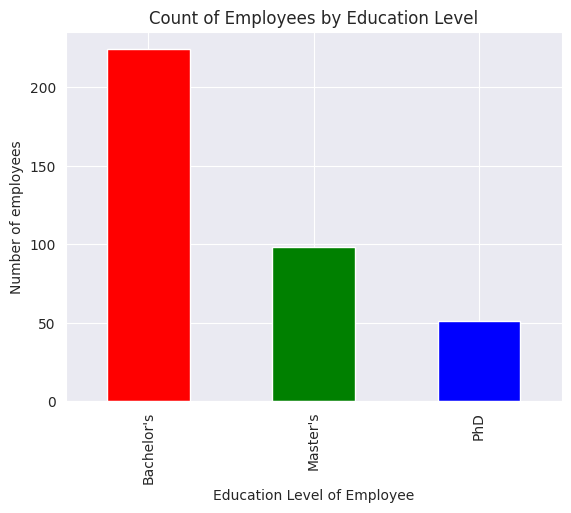

In [67]:
# bar chart of results - this part is done for you
colors = ['red', 'green', 'blue']
df['Education Level'].value_counts().plot(kind='bar', color=colors);
plt.title('Count of Employees by Education Level');
plt.xlabel('Education Level of Employee');
plt.ylabel('Number of employees');
plt.show();

`e)` What are the possible values for `Salary`? -Answer:

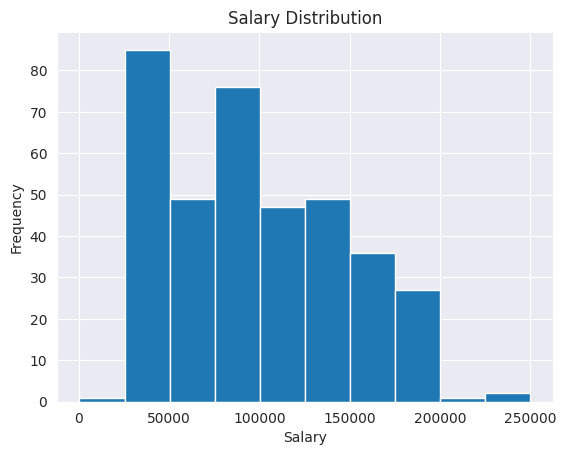

In [68]:
df['Salary'].hist()
plt.title('Salary Distribution')
plt.xlabel('Salary')
plt.ylabel('Frequency')
plt.show()

> The graph seems to be right skewed.

In [69]:
# Salary range
df['Salary'].max() , df['Salary'].min()

(250000.0, 350.0)

In [70]:
df.Salary.median()

95000.0

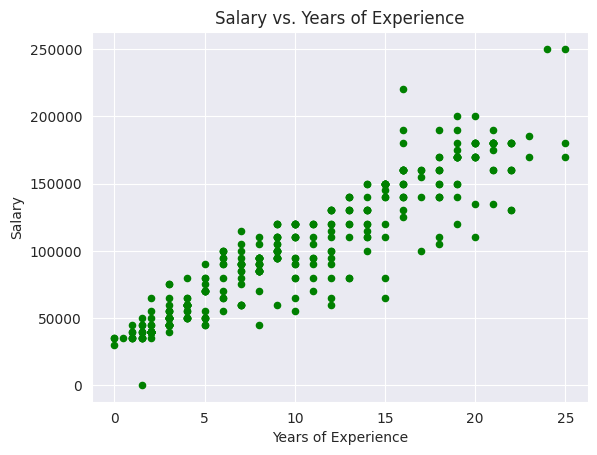

In [71]:
# check an expected relation between salary and years of experience
df.plot(x='Years of Experience', y='Salary', kind='scatter', color='Green')
plt.title('Salary vs. Years of Experience')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.show()


>A strong positive correlation between `Years of Experience` and `Salary`.

<a id='regression'></a>
#### Part II - Regression

`1.` Now that you have had a chance to learn more about the dataset, let's look more at how different factors are related to `Salary`.

`a)` Consider average salary by gender, is there evidence that salaries are higher for one gender over the other? -Answer:

In [72]:
df.groupby('Gender')['Salary'].mean()

,Salary
Gender,
Female,97011.173184
Male,103867.783505


>As shown above the average salary for a man is **103867** USD but for a woman it is only **97011** USD.

`b)` Consider average salary by education level, is there evidence that salaries are higher for increased education? -Answer:

In [73]:
df.groupby('Education Level').Salary.mean()

,Salary
Education Level,
Bachelor's,74756.026786
Master's,129795.918367
PhD,157843.137255


>The salary increases with education level.

`c)` Consider average salary by years of experience, is there evidence that salaries are associated with increased years of experience? -Answer:

In [74]:
df.groupby('Years of Experience').Salary.mean()

,Salary
Years of Experience,
0.0,33333.333333
0.5,35000.000000
1.0,37857.142857
1.5,36279.166667
2.0,41774.193548
3.0,51166.666667
4.0,58500.000000
5.0,64117.647059
6.0,83750.000000


>The salary increases with years of experience too.

`d)`  To make use of Job Title column lets create bool flag based on word existiance


List of words:

* Director
* Junior
* Senior
* Manager
* Analyst
* Engineer

**This question is completed for you**

In [75]:
df['Job Title'].value_counts()

,count
Job Title,
Director of Marketing,12
Director of Operations,11
Senior Business Analyst,10
Senior Marketing Manager,9
Senior Marketing Analyst,9
...,...
Junior Social Media Specialist,1
Junior Operations Coordinator,1
Senior HR Specialist,1


In [76]:
df.sample(5)

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
45,28.0,Female,Bachelor's,Copywriter,2.0,40000.0
274,30.0,Male,Bachelor's,Junior Business Analyst,2.0,40000.0
54,29.0,Female,Bachelor's,Graphic Designer,3.0,50000.0
237,45.0,Male,Master's,Senior Software Developer,16.0,140000.0
254,35.0,Female,Bachelor's,Senior Marketing Analyst,8.0,85000.0


In [77]:
df.iloc[45,:]

,45
Age,28.0
Gender,Female
Education Level,Bachelor's
Job Title,Copywriter
Years of Experience,2.0
Salary,40000.0


In [78]:
flag_words = ['director', 'junior', 'senior', 'manager', 'analyst', 'engineer']
df['Job Title'] = df['Job Title'].str.lower()

for word in flag_words:
    df['is_' + word] = df['Job Title'].str.contains(word)

df = df.drop('Job Title', axis=1)

In [79]:
df.sample(3)

,Age,Gender,Education Level,Years of Experience,Salary,is_director,is_junior,is_senior,is_manager,is_analyst,is_engineer
197,45.0,Male,PhD,17.0,155000.0,False,False,True,False,True,False
188,50.0,Female,PhD,22.0,180000.0,True,False,False,False,False,False
14,27.0,Male,Bachelor's,2.0,40000.0,False,False,False,False,False,False


`e)` Create a flag for gender where 1 is if a person is male and 0 if the person is not.

In [80]:
df["gender_male"] = (df["Gender"] == "Male").astype(int)

In [81]:
df.sample(1)

,Age,Gender,Education Level,Years of Experience,Salary,is_director,is_junior,is_senior,is_manager,is_analyst,is_engineer,gender_male
108,41.0,Female,Master's,14.0,100000.0,False,False,True,False,True,False,0


`f)` Use statsmodels to fit a linear model to predict salary using each of the features from `a-e`.  These include:
* Gender
* Job TItle
* Years of Experience
* Education

In [82]:
# Using Sklearn
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score,mean_absolute_error

df_sklearn = df.copy()

for col in ['is_director', 'is_junior', 'is_senior', 'is_manager', 'is_analyst', 'is_engineer']:
  df_sklearn[col] = df_sklearn[col].astype(int)

le = LabelEncoder()
df_sklearn['Education Level'] = le.fit_transform(df_sklearn['Education Level'])

df_sklearn.drop('Gender', axis=1, inplace=True)

X = df_sklearn[['gender_male', 'is_director', 'is_junior', 'is_senior', 'is_manager', 'is_analyst', 'is_engineer', 'Years of Experience', 'Education Level']]
y = df_sklearn['Salary']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2:", r2_score(y_test, y_pred))

Intercept: 34084.49284430467
Coefficients: [ 6988.47506387 29273.508527   -4983.64088942 15355.5186744
  5294.66961379 -1389.25581799  -171.82326365  4514.11814095
 14575.18952426]
MAE: 9327.374441184096
MSE: 238037744.48218042
RMSE: 15428.47187773891
R2: 0.9007175886291179


In [83]:
# smf
import statsmodels.formula.api as smf

formula = "Salary ~ gender_male + is_director + is_junior + is_senior + " \
          "is_manager + is_analyst + is_engineer + Q('Years of Experience') + Q('Education Level')"

model = smf.ols(formula=formula, data=df).fit()
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:                 Salary   R-squared:                       0.915
Model:                            OLS   Adj. R-squared:                  0.913
Method:                 Least Squares   F-statistic:                     391.7
Date:                Thu, 11 Dec 2025   Prob (F-statistic):          2.41e-187
Time:                        12:51:52   Log-Likelihood:                -4090.6
No. Observations:                 373   AIC:                             8203.
Df Residuals:                     362   BIC:                             8246.
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                                       coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
Intercep

In [84]:
#sm
import statsmodels.api as sm

df3 = df.copy()

df3['intercept']=1

# Before using sm.OLS
df3 = pd.get_dummies(df3, columns=['Education Level'], drop_first=True)

for col in ['is_director', 'is_junior', 'is_senior', 'is_manager', 'is_analyst', 'is_engineer',"Education Level_Master's","Education Level_PhD"]:
  df3[col] = df3[col].astype(int)

sm_model = sm.OLS(df3['Salary'], df3[['intercept','gender_male', 'is_director', 'is_junior', 'is_senior', 'is_manager',
                                    'is_analyst', 'is_engineer', 'Years of Experience', "Education Level_Master's","Education Level_PhD"]])


results = sm_model.fit()
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                 Salary   R-squared:                       0.915
Model:                            OLS   Adj. R-squared:                  0.913
Method:                 Least Squares   F-statistic:                     391.7
Date:                Thu, 11 Dec 2025   Prob (F-statistic):          2.41e-187
Time:                        12:51:52   Log-Likelihood:                -4090.6
No. Observations:                 373   AIC:                             8203.
Df Residuals:                     362   BIC:                             8246.
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
intercept               

<a id='interpretation'></a>
### Part III - Interpret Results

`1.` Consider you are tasked with finding which features in your linear model are significantly related to salary.  Were there any features that were not significantly related to salary in your first model?  If not, remove those features and fit a new model.  Only keep the features that were significant from the original model. -Answer:

**The baseline categories:**
- the comparison group for 'Education Level' is 'Bachelor's.
- the comparison group for 'gender_male' is 'Female'.


**How to find significant features**

In our `smf.ols` summary, look at the `P>|t|` column for each coefficient.  
- A common rule: a feature is significant if its p‑value is less than 0.05 (or our chosen α).  
- From our printed table, significant (p < 0.05) features are:
  - `is_director`
  - `is_senior`
  - `is_manager`
  - `Education Level_Master's`
  - `Education Level_PhD`
  - `gender_male`
  - `Years of Experience`  
- Not significant (p ≥ 0.05) in the first model:
  - `is_junior` (p ≈ 0.068)
  - `is_analyst` (p ≈ 0.933)
  - `is_engineer` (p ≈ 0.508)

**Fit the reduced model**

Drop only the non‑significant terms from the formula and refit:


Now all remaining predictors should be significant in the new model.



In [85]:
import statsmodels.formula.api as smf

reduced_formula = (
    "Salary ~ gender_male + is_director + is_senior + is_manager + "\
    "Q('Years of Experience')+Q('Education Level')"
)

reduced_model = smf.ols(formula=reduced_formula, data=df).fit()
print(reduced_model.summary())

                            OLS Regression Results                            
Dep. Variable:                 Salary   R-squared:                       0.914
Model:                            OLS   Adj. R-squared:                  0.913
Method:                 Least Squares   F-statistic:                     557.4
Date:                Thu, 11 Dec 2025   Prob (F-statistic):          1.46e-190
Time:                        12:51:53   Log-Likelihood:                -4092.6
No. Observations:                 373   AIC:                             8201.
Df Residuals:                     365   BIC:                             8233.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                                       coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
Intercep

>We can compare R² / Adj. R² between the full and reduced models and note that we didn't loss much explanatory power.

In [86]:
p = reduced_model.params
print(p)
print('\n')
print(
    f"Salary = {p['Intercept']:.1f}"
    f" + {p['gender_male']:.1f}*gender_male"
    f" + {p['is_director[T.True]']:.1f}*is_director"
    f" + {p['is_senior[T.True]']:.1f}*is_senior"
    f" + {p['is_manager[T.True]']:.1f}*is_manager"
    f" + {p[4]:.1f}*Education_Level_Master"
    f" + {p[5]:.1f}*Education_Level_PhD"
    f" + {p[7]:.1f}*Years_of_Experience"
)


Intercept                           28760.783767
is_director[T.True]                 24980.843209
is_senior[T.True]                   14446.475663
is_manager[T.True]                   4284.659473
Q('Education Level')[T.Master's]    14037.318361
Q('Education Level')[T.PhD]         23080.848715
gender_male                          7629.652144
Q('Years of Experience')             5104.438763
dtype: float64


Salary = 28760.8 + 7629.7*gender_male + 24980.8*is_director + 14446.5*is_senior + 4284.7*is_manager + 14037.3*Education_Level_Master + 23080.8*Education_Level_PhD + 5104.4*Years_of_Experience




\[
\begin{aligned}
\text{Expected_Salary} =\;& 28760.8
+ 7629.7 \cdot \text{gender_male}
+ 24980.8 \cdot \text{is_director}
+ 14446.5 \cdot \text{is_senior} \\
&+ 4284.7 \cdot \text{is_manager}
+ 14037.3 \cdot \text{Education_Level_Master} \\
&+ 23080.8 \cdot \text{Education_Level_PhD}
+ 5104.4 \cdot \text{Years_of_Experience}
\end{aligned}
\]




`a)` With each additional year of experience, what is the expected change in salary?  What is the 95% confidence interval of the change? -Answer:

~ **5104.4 $**

`b)` What is the expected difference in salary between someone with a senior title and someone with none of the other title indications? -Answer:



*   From the model coefficients, the coefficient for is_senior is $\$14,446$
*   This means that, on average, a person with a Senior title is expected to earn $14,446 more than a person with no director, senior, or manager title, assuming they have the same gender, years of experience, and education level.



`c)` What is the expected difference in salary between someone with a PhD and an individual with no PhD nor master's degree?  What is the 95% confidence interval of the change? -Answer:

>The 95% confidence interval for the `Education Level_PhD` coefficient is **17,700**, **28,500** USD (approx), meaning we are 95% confident that the true salary premium for a PhD holder lies within this range.

`d)` If a male employee has 5 years of experience as a senior engineer with a bachelor's degree, what is the expected salary of the employee? -Answer:

**Acknowledge the ambiguity:** "Since the specific role 'Senior Engineer' contains two components, 'Senior' and 'Engineer', and the reduced model only retains the statistically significant dummy $\text{is_senior}$, we will assume the primary pay factor is the **'Senior' title**."


\[
\begin{aligned}
\text{Expected_Salary} =\;& 28760.8
+ 7629.7 \cdot 1 (gender-male)
+ 14446.5 \cdot 1 (is-senior)
+ 5104.4 \cdot 5 (years)
\end{aligned}
\]


\[
\begin{aligned}
\text{Expected_Salary} =\;& 28760.8
+ 7629.7 \cdot 1
+ 14446.5 \cdot 1
+ 5104.4 \cdot 5
\end{aligned}
\]

In [87]:
Expected_Salary=28760.8+7629.7*1+14446.5*1+5104.4*5
Expected_Salary

76359.0

`e)` Imagine that the employee in question `d)` actually has a salary of $110,000, what would the residual be for this employee? -Answer:

In [88]:
Residual = 110000-Expected_Salary
Residual

33641.0

`f)` How well do you think your model fits?  What metrics or plots would you consider to understand if this model does a good job of predicting salary? -Answer:

Based on the quantitative metrics from our model summary, the model fits the data very well.
* High $\text{R-squared (0.914)}$: The model explains approximately 91.4% of the variability in salary, which is a very strong result for a linear regression model.